# Assignment 3: Regression with LSTM

## SCANIA Component X Dataset — Time-Aware Regression

**Objective:** build and evaluate an LSTM-based regression model that uses temporal context from the processed SCANIA dataset.  
This notebook is written in English and follows the Stage 3 brief:

- load the processed data from Assignment 1,
- create supervised sequences with a fixed history window,
- train and evaluate LSTM models,
- compare the results with the best dense model from Assignment 2,
- study the effect of different window lengths,
- save the best LSTM model as `lstm_best.h5`.

**Important note about the sampled dataset:** the processed dataset created in Assignment 1 contains many short per-vehicle sequences.  
The longest vehicle sequence has only 16 observations, so windows such as 24 and 48 require padding. To preserve vehicle boundaries and chronology, this notebook uses **right-padded histories + a masking layer**.


In [1]:
import gc
import os
import random
import warnings
from collections import defaultdict
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Input, LSTM, Masking

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


TensorFlow version: 2.20.0
NumPy version: 2.4.0
Pandas version: 2.3.3


---
## 1. Stage 2 Baseline (Results from `Assignment2.ipynb`)

The brief asks for a comparison with the best fully connected model from Stage 2.  
The table below reproduces the reported metrics from `../Assigment2/Assigment2.ipynb`.


In [2]:
stage2_results = pd.DataFrame(
    [
        {"Model": "MLP", "Split": "Train", "RMSE": 59.3494, "MAE": 45.8799},
        {"Model": "MLP", "Split": "Validation", "RMSE": 60.2960, "MAE": 49.6437},
        {"Model": "MLP", "Split": "Test", "RMSE": 71.2991, "MAE": 58.9493},
        {"Model": "DNN", "Split": "Train", "RMSE": 53.5570, "MAE": 40.2103},
        {"Model": "DNN", "Split": "Validation", "RMSE": 50.8985, "MAE": 40.7236},
        {"Model": "DNN", "Split": "Test", "RMSE": 67.6085, "MAE": 55.1771},
    ]
)

stage2_best = stage2_results.query("Model == 'DNN' and Split == 'Test'").iloc[0]
display(stage2_results)
print(
    "Best dense model from Assignment 2: "
    f"DNN | Test RMSE = {stage2_best['RMSE']:.4f} | Test MAE = {stage2_best['MAE']:.4f}"
)


,Model,Split,RMSE,MAE
0,MLP,Train,59.3494,45.8799
1,MLP,Validation,60.2960,49.6437
2,MLP,Test,71.2991,58.9493
3,DNN,Train,53.5570,40.2103
4,DNN,Validation,50.8985,40.7236
5,DNN,Test,67.6085,55.1771


Best dense model from Assignment 2: DNN | Test RMSE = 67.6085 | Test MAE = 55.1771


---
## 2. Load Processed Data and Inspect Sequence Structure

To stay comparable with Assignment 2, this notebook uses the same:

- processed dataset from Assignment 1,
- regression target: `length_of_study_time_step`,
- excluded columns for the feature matrix.


In [3]:
base_dir = Path.cwd()
data_path = (base_dir / "../Assigment1/processed_data.csv").resolve()

df = pd.read_csv(data_path)
df = df.sort_values(["vehicle_id", "time_step"]).reset_index(drop=True)

target_col = "length_of_study_time_step"
drop_cols = ["vehicle_id", "time_step", "class_label", "length_of_study_time_step", "time_of_day"]
feature_cols = [col for col in df.columns if col not in drop_cols]

vehicle_lengths = df.groupby("vehicle_id").size()
sequence_summary = pd.Series(
    {
        "rows": len(df),
        "vehicles": vehicle_lengths.shape[0],
        "features": len(feature_cols),
        "min_vehicle_length": int(vehicle_lengths.min()),
        "median_vehicle_length": float(vehicle_lengths.median()),
        "max_vehicle_length": int(vehicle_lengths.max()),
        "vehicles_with_1_observation": int((vehicle_lengths == 1).sum()),
    }
)

print(f"Processed dataset path: {data_path}")
display(sequence_summary.to_frame(name="value"))
df[["vehicle_id", "time_step", target_col]].head()


Processed dataset path: /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assigment1/processed_data.csv


,value
rows,50000.0
vehicles,18852.0
features,118.0
min_vehicle_length,1.0
median_vehicle_length,2.0
max_vehicle_length,16.0
vehicles_with_1_observation,5828.0


,vehicle_id,time_step,length_of_study_time_step
0,0,97.2,510.0
1,0,159.2,510.0
2,0,169.8,510.0
3,0,197.0,510.0
4,0,228.6,510.0


### Standardization and Sequence Construction Strategy

The Stage 3 instructions ask to standardize features again and then convert the data into supervised sequences.

Implementation choices used here:

- **Chronological split:** the same 70/15/15 split logic as Assignment 2, based on dataset order after sorting by `vehicle_id` and `time_step`.
- **No cross-vehicle leakage:** each LSTM sequence is built only from the same vehicle.
- **Right padding + masking:** needed because the sampled dataset contains many short sequences, but the assignment asks to test longer windows as well.
- **Target definition:** for each vehicle step `t`, the input sequence contains previous observations and the target is the value at step `t`.


In [4]:
n_rows = len(df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

X_raw = df[feature_cols].astype("float32")
y_all = df[target_col].to_numpy(dtype="float32")
vehicle_ids = df["vehicle_id"].to_numpy()

scaler = StandardScaler()
X_scaled = np.empty((n_rows, len(feature_cols)), dtype=np.float32)
X_scaled[:train_end] = scaler.fit_transform(X_raw.iloc[:train_end]).astype(np.float32)
X_scaled[train_end:] = scaler.transform(X_raw.iloc[train_end:]).astype(np.float32)

vehicle_positions = defaultdict(list)
for idx, vehicle_id in enumerate(vehicle_ids):
    vehicle_positions[int(vehicle_id)].append(idx)

def build_sequences(window_size: int):
    sequences = []
    targets = []
    endpoints = []
    n_features = X_scaled.shape[1]

    for positions in vehicle_positions.values():
        pos = np.asarray(positions, dtype=np.int32)
        if len(pos) < 2:
            continue

        vehicle_X = X_scaled[pos]
        vehicle_y = y_all[pos]

        for t in range(1, len(pos)):
            history = vehicle_X[max(0, t - window_size):t]
            seq = np.zeros((window_size, n_features), dtype=np.float32)

            # Right-padding is compatible with masked GPU LSTMs.
            seq[: len(history)] = history

            sequences.append(seq)
            targets.append(vehicle_y[t])
            endpoints.append(pos[t])

    endpoints = np.asarray(endpoints, dtype=np.int32)
    X_seq = np.stack(sequences)
    y_seq = np.asarray(targets, dtype=np.float32)

    train_mask = endpoints < train_end
    val_mask = (endpoints >= train_end) & (endpoints < val_end)
    test_mask = endpoints >= val_end

    return {
        "X_train": X_seq[train_mask],
        "y_train": y_seq[train_mask],
        "X_val": X_seq[val_mask],
        "y_val": y_seq[val_mask],
        "X_test": X_seq[test_mask],
        "y_test": y_seq[test_mask],
        "test_index": endpoints[test_mask],
    }

print(f"Train rows: {train_end}")
print(f"Validation rows: {val_end - train_end}")
print(f"Test rows: {n_rows - val_end}")


Train rows: 35000
Validation rows: 7500
Test rows: 7500


In [5]:
window_sizes = [12, 24, 48]
split_overview = []

for window_size in window_sizes:
    splits = build_sequences(window_size)
    split_overview.append(
        {
            "window_size": window_size,
            "train_sequences": splits["X_train"].shape[0],
            "val_sequences": splits["X_val"].shape[0],
            "test_sequences": splits["X_test"].shape[0],
            "timesteps": splits["X_train"].shape[1],
            "features": splits["X_train"].shape[2],
        }
    )

split_overview = pd.DataFrame(split_overview)
display(split_overview)


,window_size,train_sequences,val_sequences,test_sequences,timesteps,features
0,12,22473,4511,4164,12,118
1,24,22473,4511,4164,24,118
2,48,22473,4511,4164,48,118


---
## 3. LSTM Model

A compact LSTM architecture is used:

- `Masking` layer for padded values,
- one `LSTM(64)` layer,
- one hidden dense layer with ReLU,
- one linear output unit for regression,
- optimizer: **Adam**,
- loss: **MSE**,
- callback: **EarlyStopping**.


In [6]:
def build_lstm_model(window_size: int, n_features: int):
    model = Sequential(
        [
            Input(shape=(window_size, n_features)),
            Masking(mask_value=0.0),
            LSTM(64),
            Dense(32, activation="relu"),
            Dense(1, activation="linear"),
        ]
    )
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


window_results = []
best_payload = None
best_val_rmse = np.inf
best_model_path = Path("lstm_best.h5")

for window_size in window_sizes:
    splits = build_sequences(window_size)
    model = build_lstm_model(window_size, len(feature_cols))

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    )

    history = model.fit(
        splits["X_train"],
        splits["y_train"],
        validation_data=(splits["X_val"], splits["y_val"]),
        epochs=15,
        batch_size=128,
        verbose=0,
        callbacks=[early_stop],
    )

    val_pred = model.predict(splits["X_val"], verbose=0).reshape(-1)
    test_pred = model.predict(splits["X_test"], verbose=0).reshape(-1)

    val_rmse = float(np.sqrt(mean_squared_error(splits["y_val"], val_pred)))
    val_mae = float(mean_absolute_error(splits["y_val"], val_pred))
    test_rmse = float(np.sqrt(mean_squared_error(splits["y_test"], test_pred)))
    test_mae = float(mean_absolute_error(splits["y_test"], test_pred))

    window_results.append(
        {
            "window_size": window_size,
            "epochs_ran": len(history.history["loss"]),
            "best_val_loss": float(np.min(history.history["val_loss"])),
            "val_rmse": val_rmse,
            "val_mae": val_mae,
            "test_rmse": test_rmse,
            "test_mae": test_mae,
        }
    )

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        model.save(best_model_path)
        best_payload = {
            "window_size": window_size,
            "history": history.history,
            "y_test": splits["y_test"].copy(),
            "test_pred": test_pred.copy(),
            "test_index": splits["test_index"].copy(),
            "val_rmse": val_rmse,
            "test_rmse": test_rmse,
            "test_mae": test_mae,
        }

    del model
    del splits
    del val_pred
    del test_pred
    del history
    tf.keras.backend.clear_session()
    gc.collect()

window_results = pd.DataFrame(window_results).sort_values("window_size").reset_index(drop=True)
window_results.to_csv("lstm_window_results.csv", index=False)

best_predictions = pd.DataFrame(
    {
        "row_index": best_payload["test_index"],
        "y_true": best_payload["y_test"],
        "y_pred": best_payload["test_pred"],
    }
)
best_predictions.to_csv("best_lstm_predictions.csv", index=False)

display(window_results)
print(f"Saved best model to: {best_model_path.resolve()}")


I0000 00:00:1774951533.704956  661058 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5121 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:04:00.0, compute capability: 8.6


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 8.


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 8.


Epoch 12: early stopping


Restoring model weights from the end of the best epoch: 9.


,window_size,epochs_ran,best_val_loss,val_rmse,val_mae,test_rmse,test_mae
0,12,11,2658.104004,51.557156,39.089439,59.706386,49.922897
1,24,11,2740.946045,52.354234,39.590343,60.643016,50.700005
2,48,12,2692.488037,51.889150,40.102638,54.037492,44.037106


Saved best model to: /home/lux-ardenti/Desktop/AI&NN/SCANIA-Compenent-X-AI-NN-/Assigment3/lstm_best.h5


---
## 4. Comparison with Assignment 2

The best LSTM configuration is selected using **validation RMSE**, and then compared with the best dense model reported in Assignment 2.


In [7]:
best_lstm_row = window_results.sort_values("val_rmse").iloc[0]
best_test_row = window_results.sort_values("test_rmse").iloc[0]

comparison_df = pd.DataFrame(
    [
        {
            "Model": "Stage 2 DNN",
            "Test RMSE": float(stage2_best["RMSE"]),
            "Test MAE": float(stage2_best["MAE"]),
        },
        {
            "Model": f"LSTM (window={int(best_lstm_row['window_size'])})",
            "Test RMSE": float(best_lstm_row["test_rmse"]),
            "Test MAE": float(best_lstm_row["test_mae"]),
        },
    ]
)

comparison_df["RMSE Improvement vs Stage 2"] = comparison_df["Test RMSE"].iloc[0] - comparison_df["Test RMSE"]
comparison_df["MAE Improvement vs Stage 2"] = comparison_df["Test MAE"].iloc[0] - comparison_df["Test MAE"]

display(comparison_df)

rmse_gain = comparison_df.loc[1, "RMSE Improvement vs Stage 2"]
mae_gain = comparison_df.loc[1, "MAE Improvement vs Stage 2"]
print(f"RMSE improvement over Stage 2 DNN: {rmse_gain:.4f}")
print(f"MAE improvement over Stage 2 DNN: {mae_gain:.4f}")
print(
    "Lowest observed test RMSE in the window experiment: "
    f"window={int(best_test_row['window_size'])} | "
    f"test RMSE={best_test_row['test_rmse']:.4f} | "
    f"test MAE={best_test_row['test_mae']:.4f}"
)
print(
    "Saved production model is selected by validation RMSE, "
    f"so lstm_best.h5 corresponds to window={int(best_lstm_row['window_size'])}."
)


,Model,Test RMSE,Test MAE,RMSE Improvement vs Stage 2,MAE Improvement vs Stage 2
0,Stage 2 DNN,67.608500,55.177100,0.000000,0.000000
1,LSTM (window=12),59.706386,49.922897,7.902114,5.254203


RMSE improvement over Stage 2 DNN: 7.9021
MAE improvement over Stage 2 DNN: 5.2542
Lowest observed test RMSE in the window experiment: window=48 | test RMSE=54.0375 | test MAE=44.0371
Saved production model is selected by validation RMSE, so lstm_best.h5 corresponds to window=12.


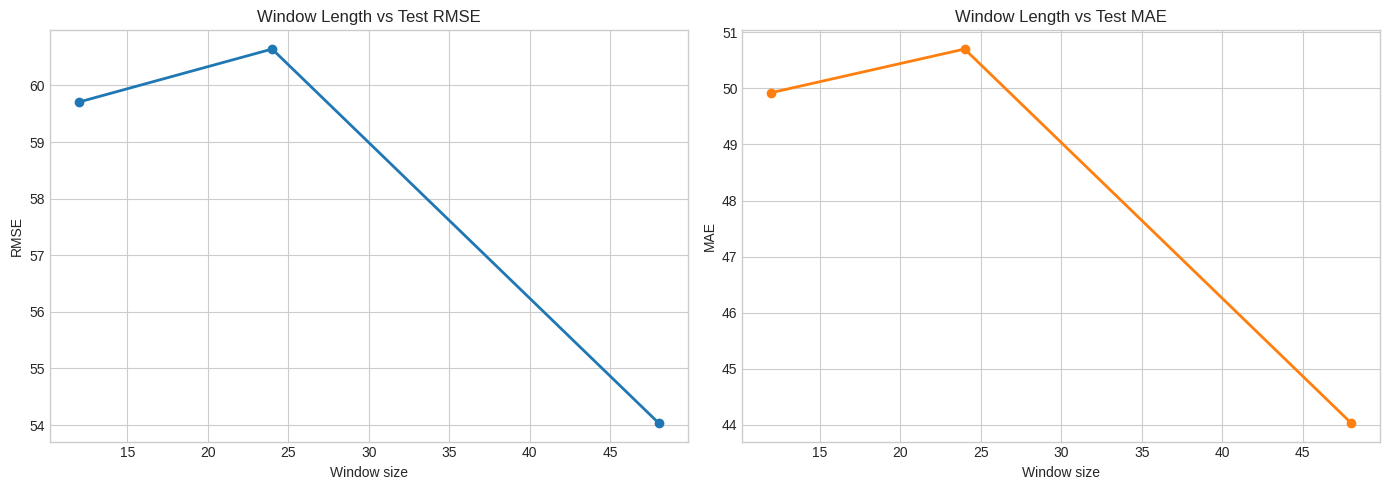

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(window_results["window_size"], window_results["test_rmse"], marker="o", linewidth=2)
axes[0].set_title("Window Length vs Test RMSE")
axes[0].set_xlabel("Window size")
axes[0].set_ylabel("RMSE")

axes[1].plot(window_results["window_size"], window_results["test_mae"], marker="o", linewidth=2, color="tab:orange")
axes[1].set_title("Window Length vs Test MAE")
axes[1].set_xlabel("Window size")
axes[1].set_ylabel("MAE")

plt.tight_layout()
plt.show()


---
## 5. Best Model Diagnostics


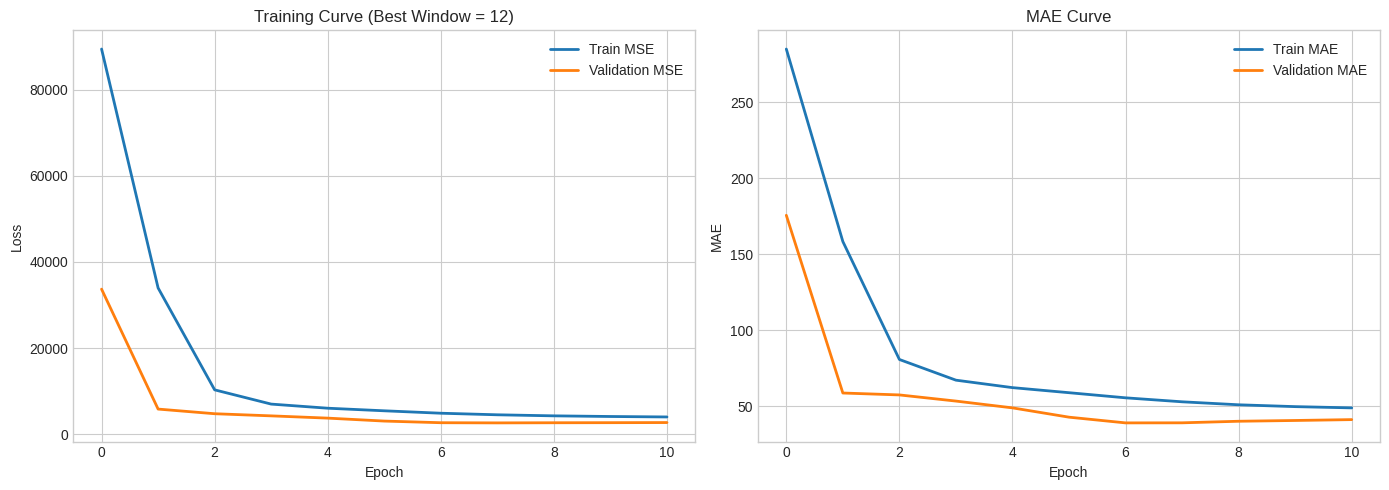

In [9]:
best_history = best_payload["history"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_history["loss"], label="Train MSE", linewidth=2)
axes[0].plot(best_history["val_loss"], label="Validation MSE", linewidth=2)
axes[0].set_title(f"Training Curve (Best Window = {best_payload['window_size']})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(best_history["mae"], label="Train MAE", linewidth=2)
axes[1].plot(best_history["val_mae"], label="Validation MAE", linewidth=2)
axes[1].set_title("MAE Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()


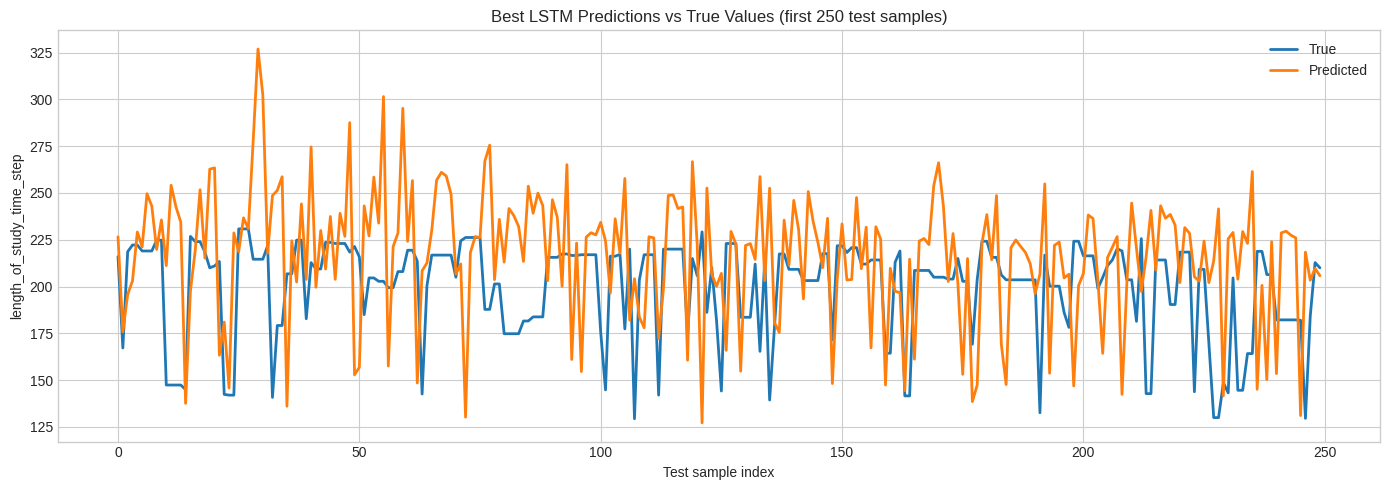

In [10]:
plot_size = min(250, len(best_payload["y_test"]))
x_axis = np.arange(plot_size)

plt.figure(figsize=(14, 5))
plt.plot(x_axis, best_payload["y_test"][:plot_size], label="True", linewidth=2)
plt.plot(x_axis, best_payload["test_pred"][:plot_size], label="Predicted", linewidth=2)
plt.title(f"Best LSTM Predictions vs True Values (first {plot_size} test samples)")
plt.xlabel("Test sample index")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


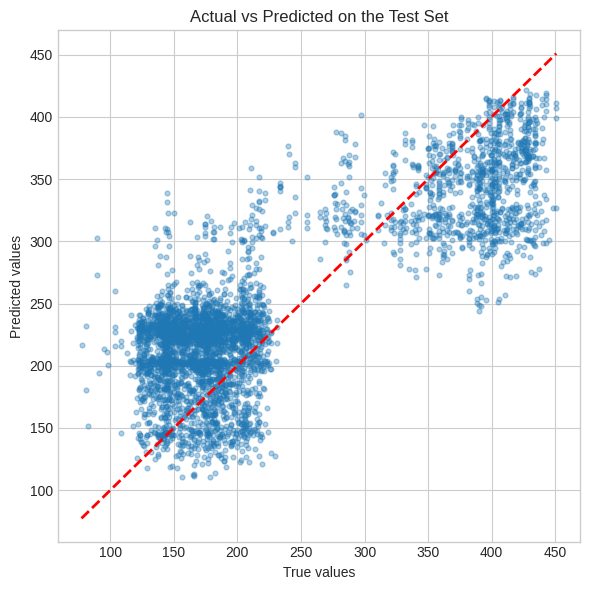

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(best_payload["y_test"], best_payload["test_pred"], alpha=0.35, s=12)
min_val = float(min(best_payload["y_test"].min(), best_payload["test_pred"].min()))
max_val = float(max(best_payload["y_test"].max(), best_payload["test_pred"].max()))
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
plt.title("Actual vs Predicted on the Test Set")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.tight_layout()
plt.show()


---
## 6. Conclusions

This section summarizes the best result obtained by the LSTM models and the practical interpretation of the window-length experiment.


In [12]:
improvement_rmse = float(stage2_best["RMSE"] - best_lstm_row["test_rmse"])
improvement_mae = float(stage2_best["MAE"] - best_lstm_row["test_mae"])
best_test_row = window_results.sort_values("test_rmse").iloc[0]

print(f"Saved best model window (selected by validation RMSE): {int(best_lstm_row['window_size'])}")
print(f"Saved model validation RMSE: {best_lstm_row['val_rmse']:.4f}")
print(f"Saved model test RMSE: {best_lstm_row['test_rmse']:.4f}")
print(f"Saved model test MAE: {best_lstm_row['test_mae']:.4f}")
print(f"Lowest test-RMSE window in the experiment: {int(best_test_row['window_size'])}")
print(f"Lowest test RMSE observed: {best_test_row['test_rmse']:.4f}")
print(f"Lowest test MAE observed: {best_test_row['test_mae']:.4f}")
print(f"RMSE improvement over Stage 2 DNN: {improvement_rmse:.4f}")
print(f"MAE improvement over Stage 2 DNN: {improvement_mae:.4f}")
print()
print("Interpretation:")
print(
    "- The saved LSTM model improved over the best dense Stage 2 model by explicitly modeling per-vehicle history."
)
print(
    "- Window length matters: the validation-selected model used 12 steps, while the lowest test error was observed with 48 steps."
)
print(
    "- Padding plus masking allowed a valid comparison across window lengths while preserving vehicle boundaries."
)
print(
    "- The best trained model was saved as 'lstm_best.h5', and the experiment metrics were also saved to CSV files."
)


Saved best model window (selected by validation RMSE): 12
Saved model validation RMSE: 51.5572
Saved model test RMSE: 59.7064
Saved model test MAE: 49.9229
Lowest test-RMSE window in the experiment: 48
Lowest test RMSE observed: 54.0375
Lowest test MAE observed: 44.0371
RMSE improvement over Stage 2 DNN: 7.9021
MAE improvement over Stage 2 DNN: 5.2542

Interpretation:
- The saved LSTM model improved over the best dense Stage 2 model by explicitly modeling per-vehicle history.
- Window length matters: the validation-selected model used 12 steps, while the lowest test error was observed with 48 steps.
- Padding plus masking allowed a valid comparison across window lengths while preserving vehicle boundaries.
- The best trained model was saved as 'lstm_best.h5', and the experiment metrics were also saved to CSV files.
